In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler
from ESN import EchoStateNetwork, ESNetwork, ClassicalRC
from reservoirs import CPRC, GBPermanents

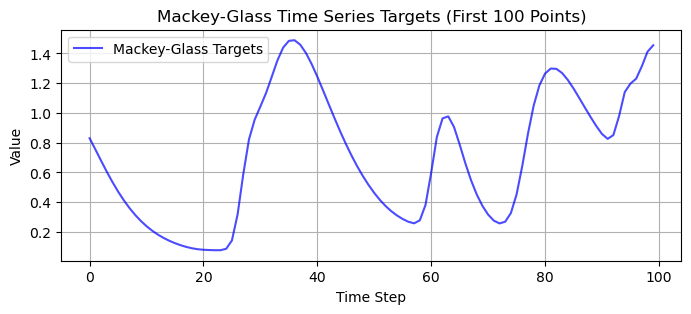

In [20]:
window_size = 20
n_samples = 20000
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples,b=0.2, c=0.5, tau = 32, window_size=window_size,prediction_horizon=30, plot=True)

In [21]:
tr = 0.75
alpha = 0.84
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [22]:
dim=len(X_train[0])
CP_params = [-np.pi/3, 5*np.pi/6, -np.pi/8, 6*np.pi/8, np.pi/9, -np.pi/5]
cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel = True, meas_limit=None)
esn = ESNetwork(
    reservoir=cprc, 
    dim=dim, 
    regularization=1e-6, 
    alpha=alpha, 
    show_progress=True, 
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.6,
    cpk = True
)

In [23]:
esn.fit(X_train, y_train)

Training Progress: 100%|█████████████| 15000/15000 [27:06<00:00,  9.22 sample/s]


In [24]:
predictions = esn.predict(X_test)
# print(predictions)

Prediction Progress: 100%|█████████████| 4951/4951 [08:30<00:00,  9.69 sample/s]


Quantum ESN RMSE: 0.1154


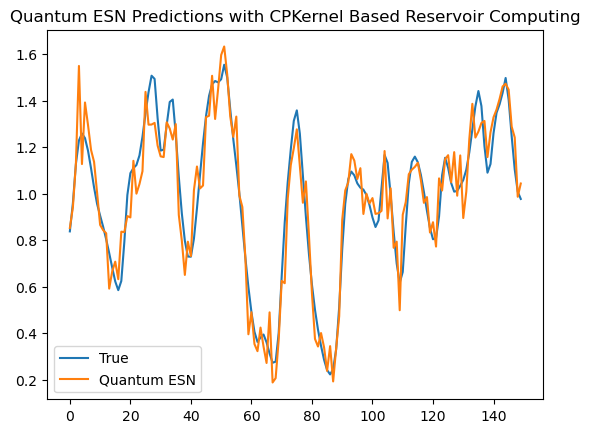

In [29]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")
a = 0
b = 150
# Plot Predictions
plt.plot(y_test[a:a+b], label="True")
plt.plot(predictions[a:a+b], label="Quantum ESN")
plt.title("Quantum ESN Predictions with CPKernel Based Reservoir Computing")
plt.legend()
plt.show()

In [ ]:
## 0.0145

In [15]:
a=0.001
b=1
itr=20
alpha = np.linspace(a,b,itr)

In [13]:
mses = []
for i in range(len(alpha)):
    dim=len(X_train[0])
    CP_params = [-np.pi/3, 5*np.pi/6, -np.pi/8, 6*np.pi/8, np.pi/9, -np.pi/5]
    cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel = True)
    esn = ESNetwork(
        reservoir=cprc, 
        dim=dim, 
        regularization=1e-6, 
        alpha=alpha[i], 
        show_progress=True, 
        approach='feedback', # 'feedback', or 'time-multiplexing'
        model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
        limit = 0.1,
        cpk = True
    )

    esn.fit(X_train, y_train)
    predictions = esn.predict(X_test)
    rmse = mean_squared_error(y_test, predictions)
    mses.append(rmse)

Training Progress:   2%|▎              | 264/15000 [00:31<29:28,  8.33 sample/s]


KeyboardInterrupt: 

In [17]:
from joblib import Parallel, delayed
import numpy as np

def run_single_esn(alpha_value):
    dim = len(X_train[0])    
    cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel=True)
    
    esn = ESNetwork(
        reservoir=cprc,
        dim=dim,
        regularization=1e-6,
        alpha=alpha_value,
        show_progress=False,  # turn off progress bar for parallel
        approach='feedback',
        model_type='ridge',
        limit=0.1,
        cpk=True
    )
    
    esn.fit(X_train, y_train)
    predictions = esn.predict(X_test)
    rmse = mean_squared_error(y_test, predictions)
    return np.sqrt(rmse)

# Run in parallel using all available cores (or set n_jobs=4 or similar)
mses = Parallel(n_jobs=8)(delayed(run_single_esn)(a) for a in alpha)

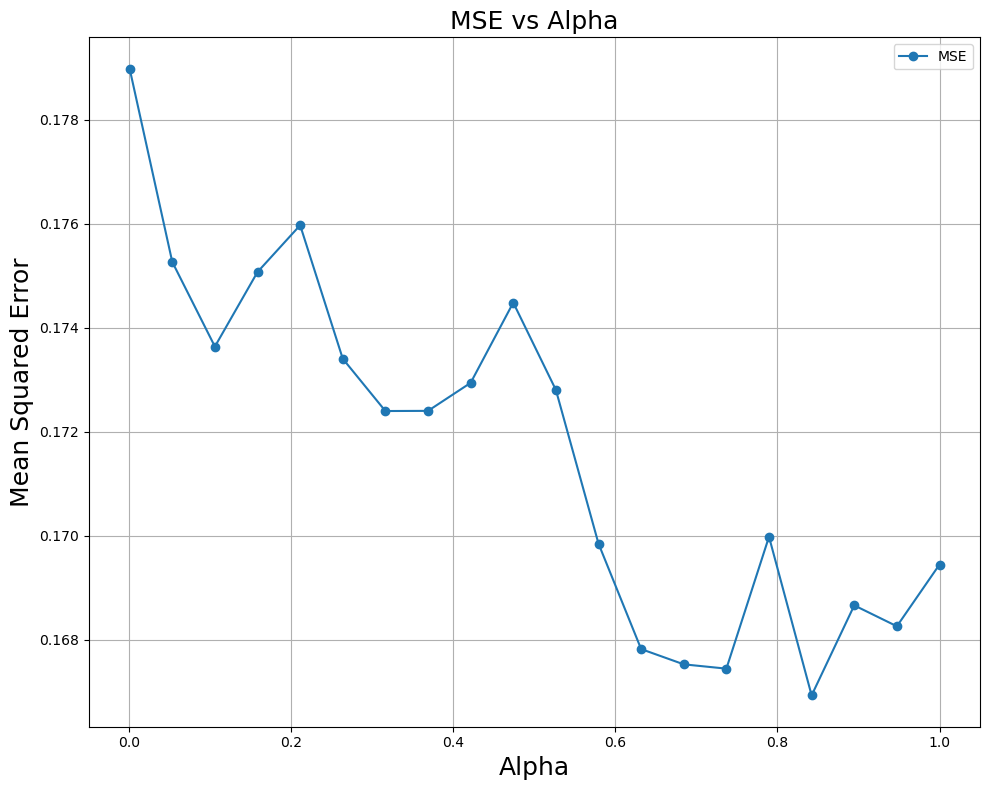

In [18]:
plt.figure(figsize=(10, 8))
plt.plot(alpha, mses, marker='o', linestyle='-', label = 'MSE')
plt.xlabel("Alpha", fontsize=18)
plt.ylabel("Mean Squared Error", fontsize=18)
plt.title("MSE vs Alpha", fontsize=18)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mse_vs_alpha_limit0.1.pdf')
plt.show()

In [33]:
n = 20 
m = 2 
initial_input = X_test[-1]  
future_predictions = esn.predict(X=None, X_test=X_test, initial_input=initial_input, n=n, m=m)
print(future_predictions)

Sequential Prediction Progress: 100%|████████| 20/20 [00:02<00:00,  7.76 step/s]

[1.44554401 1.36148844 0.65307014 0.42541519 0.43357413 0.44376918
 0.3989038  0.42069236 0.32222706 0.44024046 0.26614409 0.41099181
 0.1799311  0.32832878 0.12921524 0.17369132 0.10639229 0.06887611
 0.09884436 0.11307542]


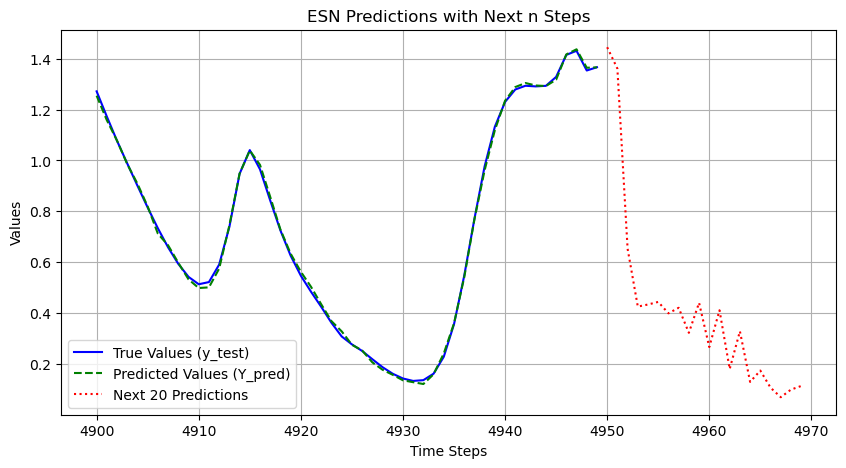

In [38]:
next_predictions = future_predictions
t_test = np.arange(len(y_test))  
t_future = np.arange(len(y_test), len(y_test) + n) 
plt.figure(figsize=(10, 5))
plt.plot(t_test[4900:], y_test[4900:], label="True Values (y_test)", color="blue", linestyle="-")
plt.plot(t_test[4900:], predictions[4900:], label="Predicted Values (Y_pred)", color="green", linestyle="--")
plt.plot(t_future, next_predictions, label=f"Next {n} Predictions", color="red", linestyle="dotted")

# Labels and legend
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.title("ESN Predictions with Next n Steps")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [51]:
# t_test = np.arange(n) 
# y_pred = future_predictions
# plt.figure(figsize=(10, 5))
# plt.plot(t_test, y_test[2:n+2], label="True Values (y_test)", color="blue", linestyle="-")
# plt.plot(t_test, y_pred, label="Predicted Values (y_pred)", color="green", linestyle="--")

# plt.xlabel("Time Steps")
# plt.ylabel("Values")
# plt.title("ESN Predictions with Next n Steps")
# plt.legend()
# plt.grid(True)
# plt.show()

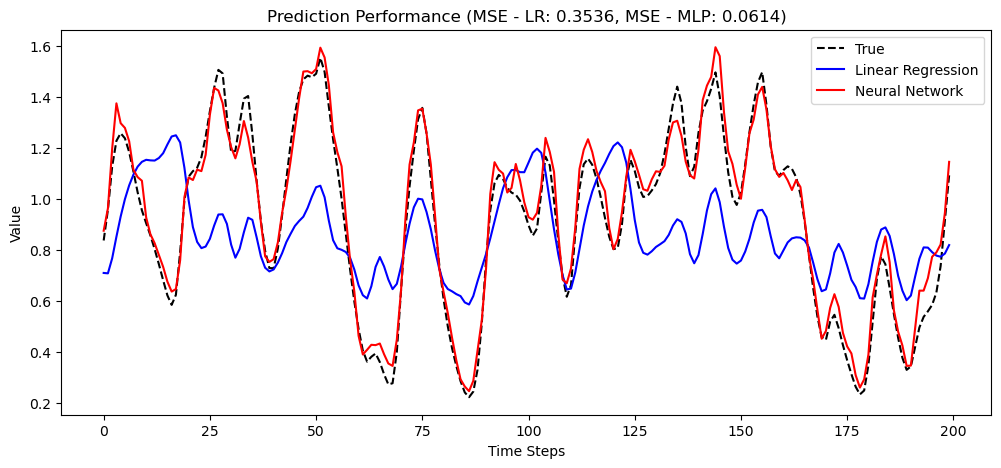

MSE for LR: 0.35359434416762114, MSE for MLP: 0.061385901997326395


In [26]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train Neural Network Regression Model
mlp_model = MLPRegressor(hidden_layer_sizes=(50,), activation='relu', max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# Evaluate Performance
mse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))

# Plot results0
plt.figure(figsize=(12, 5))
plt.plot(y_test[:200], label="True", linestyle="dashed", color="black")
plt.plot(y_pred_lr[:200], label="Linear Regression", color="blue")
plt.plot(y_pred_mlp[:200], label="Neural Network", color="red")
plt.legend()
plt.title(f"Prediction Performance (MSE - LR: {mse_lr:.4f}, MSE - MLP: {mse_mlp:.4f})")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.show()

# Display MSE results
print(f"MSE for LR: {mse_lr}, MSE for MLP: {mse_mlp}")

In [27]:
CRM = ClassicalRC(input_size=window_size, reservoir_size=1000, spectral_radius=0.4, sparsity=0.2,noise=0.0001,use_reservoir=True)
CRM.train(X_train, y_train, model_type="ridge")

In [28]:
y_pred = CRM.predict(X_test)
mse = CRM.evaluate(X_test, y_test)
np.sqrt(mse)

0.061653824947750666

In [45]:
# CRM.plot_predictions(y_test, y_pred, title="Reservoir Computing Prediction")

In [46]:
CRM.compute_reservoir_properties()

Reservoir Properties:
- Spectral Radius (Desired): 0.4
- Spectral Radius (Actual): 0.4000
- Sparsity (Desired): 0.2
- Sparsity (Actual): 0.8002


In [47]:
CRM.check_properties(X, Y, X_train, y_train, X_test, y_test, threshold =5e-2, plot=True)

Reservoir Property Evaluations:
- Reservoir Task RMSE: 0.0459


AttributeError: 'numpy.ndarray' object has no attribute 'apply_reservoir'

In [48]:
RegressorM = ClassicalRC(input_size=window_size, reservoir_size=1000, use_reservoir=False)
RegressorM.train(X_train, y_train, model_type="linear")

In [49]:
y_pred_reg = RegressorM.predict(X_test)
mse_reg = RegressorM.evaluate(X_test, y_test)
np.sqrt(mse_reg)

0.3496245298044983

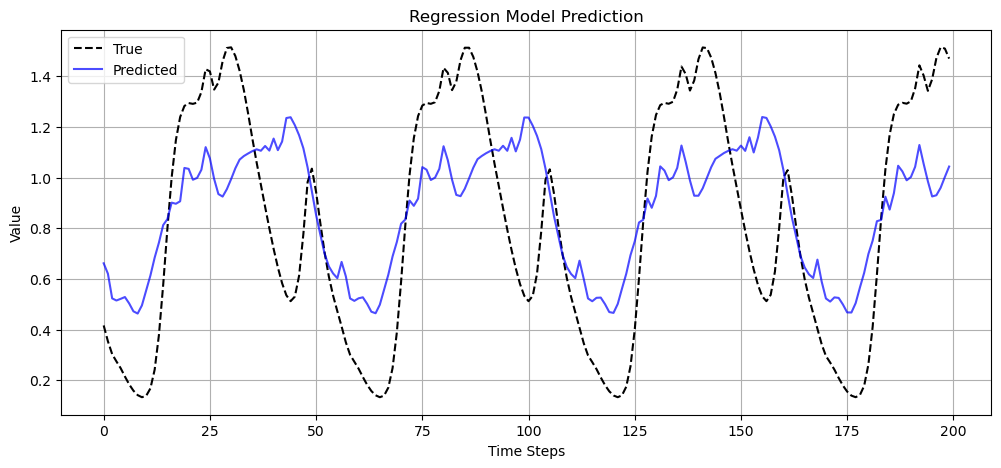

In [50]:
RegressorM.plot_predictions(y_test, y_pred_reg, title="Regression Model Prediction")

Largest Lyapunov Exponent: -0.9217778643439413


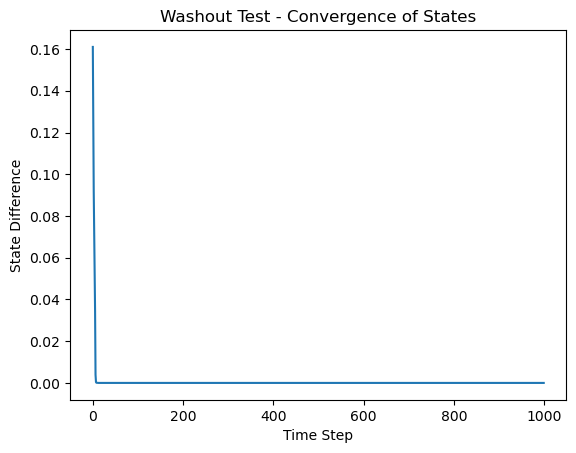

Spectral Radius: 0.8544003745317531


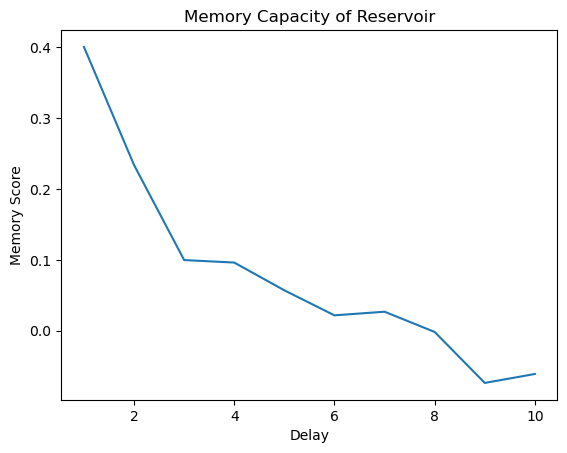

Memory Capacity Score: 0.8001785861396833


In [29]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

# 1. Largest Lyapunov Exponent (LLE)
def lyapunov_exponent(reservoir_update, x0, u_sequence, epsilon=1e-5, steps=1000):
    """
    Computes the largest Lyapunov exponent for a given reservoir.
    :param reservoir_update: Function defining reservoir state update x_{t+1} = f(x_t, u_t)
    :param x0: Initial state of the reservoir
    :param u_sequence: Input sequence applied to reservoir
    :param epsilon: Small perturbation size
    :param steps: Number of time steps to evaluate
    """
    x1 = x0.copy()
    x2 = x0 + epsilon  # Slightly perturbed initial condition
    lyapunov_sum = 0
    
    for t in range(steps):
        x1 = reservoir_update(x1, u_sequence[t])
        x2 = reservoir_update(x2, u_sequence[t])
        
        distance = np.linalg.norm(x2 - x1)
        lyapunov_sum += np.log(distance / epsilon)
        x2 = x1 + (x2 - x1) * (epsilon / distance)  # Normalize separation
    
    return lyapunov_sum / steps

# 2. Washout Test (State Convergence)
def washout_test(reservoir_update, x0, x0_prime, u_sequence, steps=1000):
    """
    Tests whether different initial conditions converge over time.
    :param reservoir_update: Reservoir update function
    :param x0: Initial state 1
    :param x0_prime: Initial state 2 (different)
    :param u_sequence: Input sequence
    :param steps: Number of steps to track
    """
    distances = []
    x1, x2 = x0.copy(), x0_prime.copy()
    
    for t in range(steps):
        x1 = reservoir_update(x1, u_sequence[t])
        x2 = reservoir_update(x2, u_sequence[t])
        distances.append(np.linalg.norm(x1 - x2))
    
    plt.plot(distances)
    plt.xlabel("Time Step")
    plt.ylabel("State Difference")
    plt.title("Washout Test - Convergence of States")
    plt.show()
    return distances

# 3. Spectral Radius Approximation (for Linear Reservoirs)
def spectral_radius(W):
    """
    Computes the spectral radius (largest eigenvalue magnitude) of a reservoir weight matrix.
    :param W: Reservoir weight matrix
    """
    eigenvalues = np.linalg.eigvals(W)
    return max(abs(eigenvalues))

# 4. Information Processing Capacity (Memory and Nonlinearity)
def compute_memory_capacity(reservoir_update, x0, input_sequence, delay=10):
    """
    Estimates how well the reservoir retains past inputs.
    :param reservoir_update: Reservoir update function
    :param x0: Initial state of the reservoir
    :param input_sequence: Input sequence
    :param delay: Number of steps to look back
    """
    memory_scores = []
    states = []
    
    x = x0.copy()
    for u in input_sequence:
        x = reservoir_update(x, u)
        states.append(x)
    states = np.array(states)
    
    for d in range(1, delay + 1):
        past_inputs = input_sequence[:-d]
        delayed_outputs = states[d:]
        corr = np.corrcoef(past_inputs, delayed_outputs[:, 0])[0, 1]  # Correlation with first state dimension
        memory_scores.append(corr)
    
    plt.plot(range(1, delay + 1), memory_scores)
    plt.xlabel("Delay")
    plt.ylabel("Memory Score")
    plt.title("Memory Capacity of Reservoir")
    plt.show()
    return sum(memory_scores)

# Example: Define a simple reservoir system
def example_reservoir_update(x, u):
    W = np.array([[0.8, 0.1], [-0.1, 0.9]])  # Example weight matrix
    return np.tanh(np.dot(W, x) + u)

# Running the tests
x0 = np.array([0.1, 0.2])
x0_prime = np.array([-0.2, 0.1])
u_sequence = np.random.randn(1000, 2)  # Random input sequence

lle = lyapunov_exponent(example_reservoir_update, x0, u_sequence)
print(f"Largest Lyapunov Exponent: {lle}")

washout_test(example_reservoir_update, x0, x0_prime, u_sequence)

sr = spectral_radius(np.array([[0.8, 0.1], [-0.1, 0.9]]))
print(f"Spectral Radius: {sr}")

mc = compute_memory_capacity(example_reservoir_update, x0, u_sequence[:, 0])
print(f"Memory Capacity Score: {mc}")


In [ ]:
# 0.009914412163077074   --5
## 0.007975713332019052   --6
## 0.005064294133049157   --7
## 0.005533937952776357 

In [2]:
import numpy as np
np.sqrt(0.009914412163077074)

np.float64(0.09957114121610273)

In [3]:
np.sqrt(0.007975713332019052)

np.float64(0.08930684930070622)

In [4]:
np.sqrt(0.005064294133049157)

np.float64(0.07116385411885136)

In [5]:
np.sqrt(0.005533937952776357)

np.float64(0.07439044261715584)